# 03. Lorenz-63 Tangent Linear Model Check

이 노트북에서는 Lorenz-63 모델의 tangent linear model, TLM을 구현하고 검증한다.

이번 실습의 목표는 다음과 같다.

1. Lorenz-63 RHS의 Jacobian을 이해한다.
2. Euler time stepping에 대한 tangent linear model을 구성한다.
3. finite-difference 방식으로 Jacobian을 검증한다.
4. nonlinear perturbation과 TLM perturbation을 비교한다.
5. TLM이 언제 잘 맞고, 언제 깨지는지 확인한다.

이번 실습은 이후 adjoint model과 4D-Var 구현의 기초가 된다.

## 1. 라이브러리 불러오기

이번 실습에서는 기존에 만든 Lorenz-63 forward model, Euler 적분기, TLM module을 사용한다.

In [1]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt

from lorenz_da.models.lorenz63 import (
    lorenz63_rhs,
    lorenz63_default_initial_condition,
)
from lorenz_da.numerics.euler import (
    euler_step,
    integrate_euler,
)
from lorenz_da.tlm.lorenz63_tlm import (
    lorenz63_jacobian,
    euler_tlm_matrix,
    euler_tlm_step,
    integrate_euler_tlm,
)
from lorenz_da.utils.diagnostics import rmse_time_series

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

노트북이 `notebooks/` 안에서 실행될 수도 있고, 프로젝트 루트에서 실행될 수도 있으므로 경로를 자동으로 설정한다.

In [2]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. Lorenz-63 Jacobian

Lorenz-63 방정식은 다음과 같다.

$$
\frac{dx}{dt} = \sigma (y - x)
$$

$$
\frac{dy}{dt} = x(\rho - z) - y
$$

$$
\frac{dz}{dt} = xy - \beta z
$$

상태벡터를

$$
\mathbf{x} =
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix}
$$

라고 하면, RHS의 Jacobian은 다음과 같다.

$$
J(\mathbf{x}) =
\frac{\partial f}{\partial \mathbf{x}}
=
\begin{bmatrix}
-\sigma & \sigma & 0 \\
\rho - z & -1 & -x \\
y & x & -\beta
\end{bmatrix}
$$

이 Jacobian은 작은 perturbation이 한 순간에 어떻게 변하는지를 선형적으로 근사한다.

In [3]:
x0 = lorenz63_default_initial_condition()

J0 = lorenz63_jacobian(x0)

print("Initial state:")
print(x0)

print("\nJacobian at initial state:")
print(J0)

Initial state:
[1. 1. 1.]

Jacobian at initial state:
[[-10.          10.           0.        ]
 [ 27.          -1.          -1.        ]
 [  1.           1.          -2.66666667]]


## 4. Euler step에 대한 TLM

Euler 방법으로 nonlinear model을 적분하면 다음과 같다.

$$
\mathbf{x}_{n+1}
=
\mathbf{x}_n
+
\Delta t f(\mathbf{x}_n)
$$

이 식을 작은 perturbation $\delta \mathbf{x}$에 대해 선형화하면 다음과 같다.

$$
\delta \mathbf{x}_{n+1}
=
\left[
I + \Delta t J(\mathbf{x}_n)
\right]
\delta \mathbf{x}_n
$$

따라서 Euler step에 대한 tangent linear matrix는 다음과 같다.

$$
M_n =
I + \Delta t J(\mathbf{x}_n)
$$

In [4]:
dt = 0.005

M0 = euler_tlm_matrix(
    state=x0,
    dt=dt,
)

print("Euler TLM matrix at initial state:")
print(M0)

Euler TLM matrix at initial state:
[[ 0.95        0.05        0.        ]
 [ 0.135       0.995      -0.005     ]
 [ 0.005       0.005       0.98666667]]


## 5. RHS Jacobian finite-difference check

먼저 Lorenz-63 RHS의 Jacobian이 맞는지 확인한다.

작은 perturbation $\delta \mathbf{x}$에 대해 다음 관계가 성립해야 한다.

$$
f(\mathbf{x} + \epsilon \delta \mathbf{x})
\approx
f(\mathbf{x})
+
\epsilon J(\mathbf{x}) \delta \mathbf{x}
$$

따라서 다음 두 값이 비슷해야 한다.

$$
\frac{
f(\mathbf{x} + \epsilon \delta \mathbf{x}) - f(\mathbf{x})
}{\epsilon}
\approx
J(\mathbf{x}) \delta \mathbf{x}
$$

In [5]:
# 기준 상태
state = np.array([1.0, 1.0, 1.0])

# 임의의 perturbation 방향
delta = np.array([0.3, -0.4, 0.2])

# perturbation 크기
epsilon = 1.0e-6

# finite-difference approximation
fd_approx = (
    lorenz63_rhs(state + epsilon * delta)
    - lorenz63_rhs(state)
) / epsilon

# tangent linear approximation
tlm_approx = lorenz63_jacobian(state) @ delta

print("Finite-difference approximation:")
print(fd_approx)

print("\nTLM approximation:")
print(tlm_approx)

print("\nDifference:")
print(fd_approx - tlm_approx)

print("\nError norm:")
print(np.linalg.norm(fd_approx - tlm_approx))

Finite-difference approximation:
[-7.          8.29999994 -0.63333345]

TLM approximation:
[-7.          8.3        -0.63333333]

Difference:
[ 3.53821861e-10 -5.93247940e-08 -1.19903795e-07]

Error norm:
1.3377771253888676e-07


## 6. epsilon 크기에 따른 finite-difference error

Finite-difference check에서는 perturbation 크기 $\epsilon$ 선택이 중요하다.

- $\epsilon$이 너무 크면 nonlinear term 때문에 선형 근사가 나빠진다.
- $\epsilon$이 너무 작으면 floating-point round-off error가 커질 수 있다.

여기서는 여러 $\epsilon$ 값에 대해 finite-difference error를 계산한다.

In [6]:
eps_list = np.logspace(-12, -1, 12)
fd_errors = []

for eps in eps_list:
    fd_approx = (
        lorenz63_rhs(state + eps * delta)
        - lorenz63_rhs(state)
    ) / eps

    tlm_approx = lorenz63_jacobian(state) @ delta

    err = np.linalg.norm(fd_approx - tlm_approx)
    fd_errors.append(err)

fd_errors = np.array(fd_errors)

for eps, err in zip(eps_list, fd_errors):
    print(f"epsilon = {eps:.1e}, error = {err:.6e}")

epsilon = 1.0e-12, error = 2.692941e-03
epsilon = 1.0e-11, error = 2.164262e-04
epsilon = 1.0e-10, error = 8.215648e-06
epsilon = 1.0e-09, error = 1.235092e-06
epsilon = 1.0e-08, error = 3.477986e-08
epsilon = 1.0e-07, error = 2.923323e-08
epsilon = 1.0e-06, error = 1.337777e-07
epsilon = 1.0e-05, error = 1.341519e-06
epsilon = 1.0e-04, error = 1.341642e-05
epsilon = 1.0e-03, error = 1.341641e-04
epsilon = 1.0e-02, error = 1.341641e-03
epsilon = 1.0e-01, error = 1.341641e-02


## 7. finite-difference error 시각화

$\epsilon$에 따른 finite-difference error를 log-log plot으로 확인한다.

보통 중간 정도의 $\epsilon$에서 error가 가장 작게 나타난다.

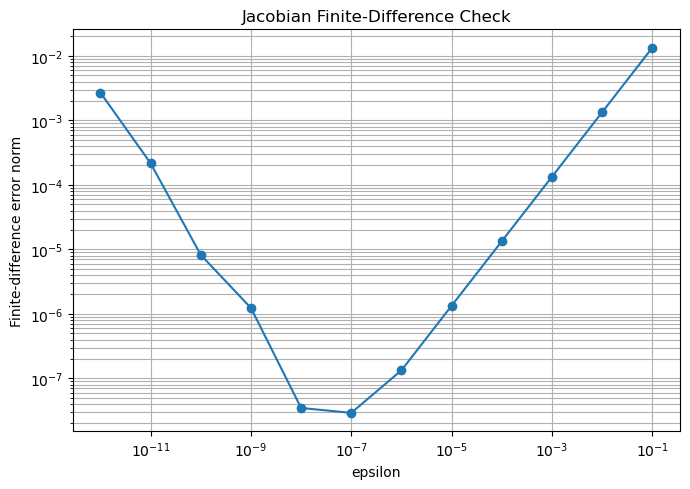

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_jacobian_finite_difference_error.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(eps_list, fd_errors, marker="o")

ax.set_xlabel("epsilon")
ax.set_ylabel("Finite-difference error norm")
ax.set_title("Jacobian Finite-Difference Check")
ax.grid(True, which="both")

fig.tight_layout()

fig_path = FIGURE_DIR / "03_jacobian_finite_difference_error.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 8. Euler step에 대한 finite-difference check

이번에는 RHS가 아니라 Euler 한 step 전체에 대한 TLM을 검증한다.

Nonlinear Euler step을 다음과 같이 둔다.

$$
M(\mathbf{x})
=
\mathbf{x}
+
\Delta t f(\mathbf{x})
$$

그러면 Euler step의 TLM은 다음을 만족해야 한다.

$$
\frac{
M(\mathbf{x} + \epsilon \delta \mathbf{x})
-
M(\mathbf{x})
}{\epsilon}
\approx
\left[
I + \Delta t J(\mathbf{x})
\right]
\delta \mathbf{x}
$$

In [8]:
epsilon = 1.0e-6

# nonlinear finite-difference approximation for one Euler step
step_fd_approx = (
    euler_step(state + epsilon * delta, dt=dt, rhs_func=lorenz63_rhs)
    - euler_step(state, dt=dt, rhs_func=lorenz63_rhs)
) / epsilon

# TLM approximation for one Euler step
step_tlm_approx = euler_tlm_matrix(state=state, dt=dt) @ delta

print("Euler step finite-difference approximation:")
print(step_fd_approx)

print("\nEuler step TLM approximation:")
print(step_tlm_approx)

print("\nDifference:")
print(step_fd_approx - step_tlm_approx)

print("\nError norm:")
print(np.linalg.norm(step_fd_approx - step_tlm_approx))

Euler step finite-difference approximation:
[ 0.265      -0.3585      0.19683333]

Euler step TLM approximation:
[ 0.265      -0.3585      0.19683333]

Difference:
[-5.62175306e-11 -1.30490507e-10 -7.00349279e-10]

Error norm:
7.146168870360298e-10


## 9. 기준 trajectory 생성

이제 TLM을 여러 time step 동안 적분해본다.

기준 trajectory는 첫 번째 실습과 같은 설정으로 만든다.

- 초기조건: `[1, 1, 1]`
- 시간간격: `dt = 0.005`
- 전체 시간: `tmax = 10`

TLM은 이 기준 trajectory를 따라 적분된다.

In [9]:
dt = 0.005
tmax = 10.0
nsteps = int(tmax / dt)

time = np.arange(nsteps + 1) * dt

x0_ref = lorenz63_default_initial_condition()

trajectory_ref = integrate_euler(
    x0=x0_ref,
    dt=dt,
    nsteps=nsteps,
    rhs_func=lorenz63_rhs,
)

print("trajectory_ref shape:", trajectory_ref.shape)
print("time shape:", time.shape)

trajectory_ref shape: (2001, 3)
time shape: (2001,)


## 10. Nonlinear perturbation trajectory 생성

작은 초기 perturbation을 추가한 trajectory를 생성한다.

기준 초기조건:

$$
\mathbf{x}_0
=
[1, 1, 1]
$$

perturbed 초기조건:

$$
\mathbf{x}_0'
=
\mathbf{x}_0
+
\epsilon \delta \mathbf{x}_0
$$

여기서는 perturbation 방향을 다음과 같이 둔다.

$$
\delta \mathbf{x}_0 = [1, 0, 0]
$$

In [10]:
delta0_direction = np.array([1.0, 0.0, 0.0])
epsilon = 1.0e-6

x0_pert = x0_ref + epsilon * delta0_direction

trajectory_pert = integrate_euler(
    x0=x0_pert,
    dt=dt,
    nsteps=nsteps,
    rhs_func=lorenz63_rhs,
)

# nonlinear perturbation을 epsilon으로 나누어 선형 perturbation 크기로 환산
nonlinear_delta = (trajectory_pert - trajectory_ref) / epsilon

print("x0_ref:", x0_ref)
print("x0_pert:", x0_pert)
print("initial nonlinear_delta:", nonlinear_delta[0])

x0_ref: [1. 1. 1.]
x0_pert: [1.000001 1.       1.      ]
initial nonlinear_delta: [1. 0. 0.]


## 11. TLM perturbation trajectory 생성

이번에는 같은 초기 perturbation을 TLM으로 적분한다.

TLM은 nonlinear trajectory 자체를 예측하는 것이 아니라, 기준 trajectory 주변의 작은 perturbation을 선형적으로 예측한다.

즉, 다음을 계산한다.

$$
\delta \mathbf{x}_{n+1}
=
\left[
I + \Delta t J(\mathbf{x}_n)
\right]
\delta \mathbf{x}_n
$$

여기서 $\mathbf{x}_n$은 기준 trajectory이다.

In [11]:
tlm_delta = integrate_euler_tlm(
    perturbation0=delta0_direction,
    reference_trajectory=trajectory_ref,
    dt=dt,
)

print("tlm_delta shape:", tlm_delta.shape)
print("initial tlm_delta:", tlm_delta[0])

tlm_delta shape: (2001, 3)
initial tlm_delta: [1. 0. 0.]


## 12. Nonlinear perturbation과 TLM perturbation 비교

이제 nonlinear perturbation과 TLM perturbation을 비교한다.

비교하는 두 값은 다음이다.

$$
\frac{
\mathbf{x}'(t) - \mathbf{x}(t)
}{\epsilon}
$$

그리고

$$
\delta \mathbf{x}_{TLM}(t)
$$

perturbation이 충분히 작고 시간이 너무 길지 않다면 두 값은 비슷해야 한다.

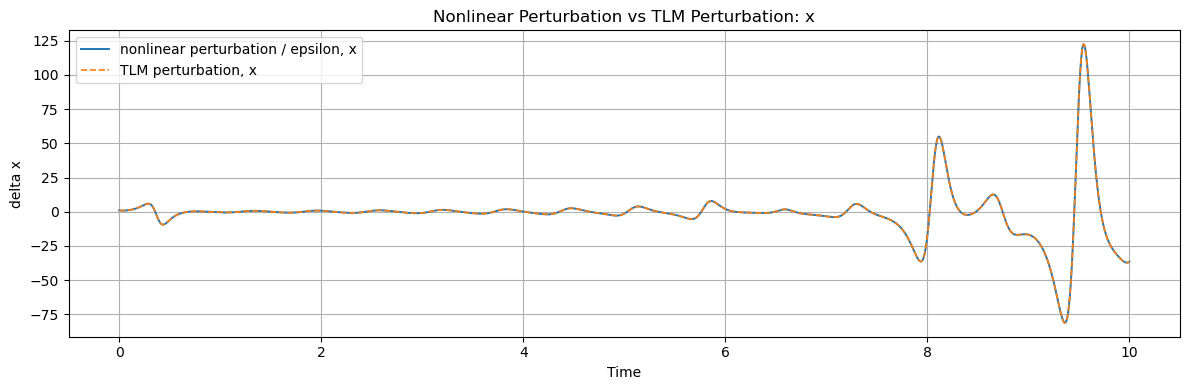

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_tlm_vs_nonlinear_delta_x.png


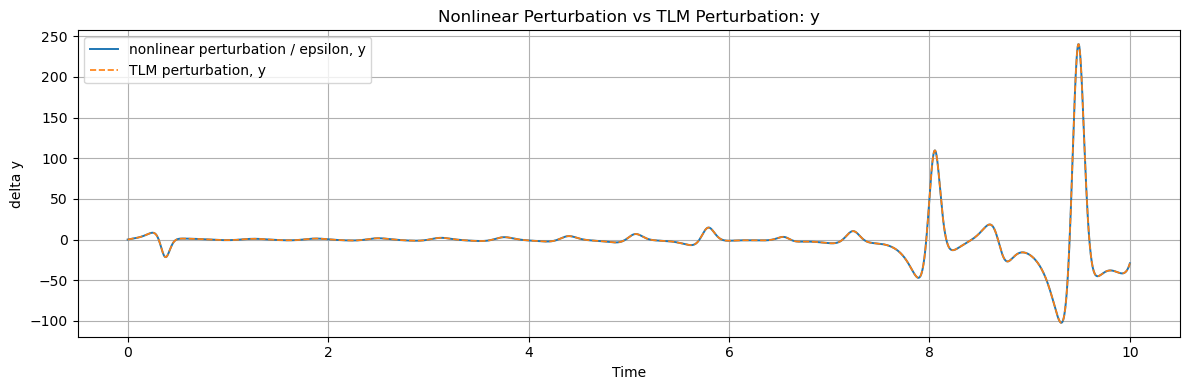

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_tlm_vs_nonlinear_delta_y.png


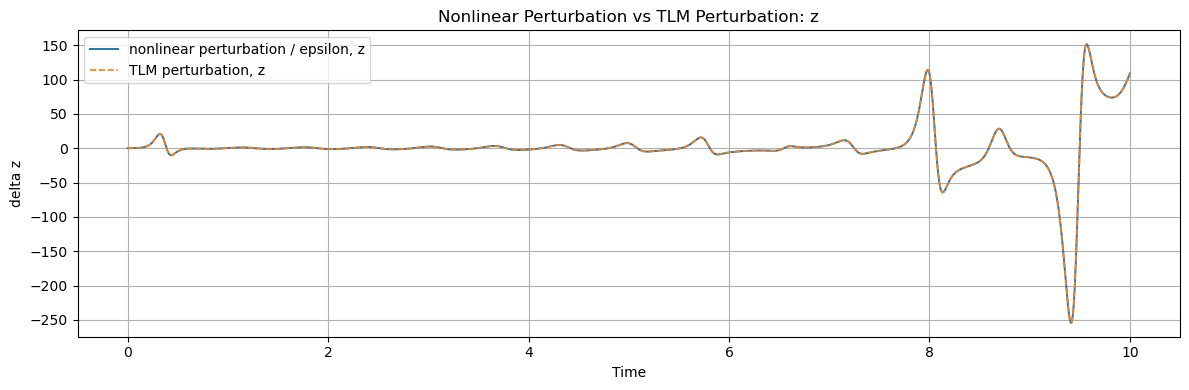

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_tlm_vs_nonlinear_delta_z.png


In [12]:
var_names = ["x", "y", "z"]

for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        time,
        nonlinear_delta[:, i],
        label=f"nonlinear perturbation / epsilon, {name}",
        linewidth=1.4,
    )
    ax.plot(
        time,
        tlm_delta[:, i],
        label=f"TLM perturbation, {name}",
        linestyle="--",
        linewidth=1.2,
    )

    ax.set_xlabel("Time")
    ax.set_ylabel(f"delta {name}")
    ax.set_title(f"Nonlinear Perturbation vs TLM Perturbation: {name}")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"03_tlm_vs_nonlinear_delta_{name}.png"
    fig.savefig(fig_path, dpi=150)

    plt.show()

    print("Saved figure:", fig_path)

## 13. TLM error 계산

TLM error를 다음과 같이 정의한다.

$$
e(t)
=
\left\|
\frac{
\mathbf{x}'(t) - \mathbf{x}(t)
}{\epsilon}
-
\delta \mathbf{x}_{TLM}(t)
\right\|_2
$$

TLM이 잘 작동하면 짧은 시간 동안 이 값이 작아야 한다.

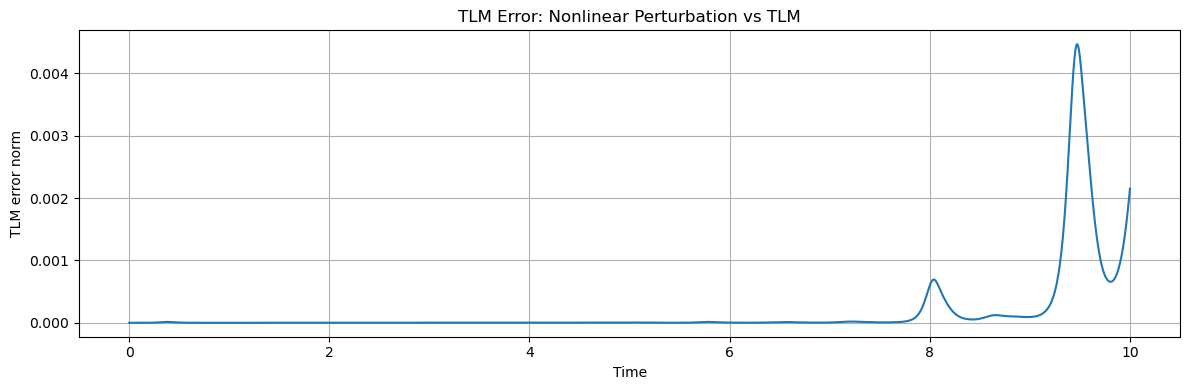

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_tlm_error_time_series.png
Initial TLM error: 8.22666379463044e-11
Final TLM error: 0.002151968467920877


In [13]:
tlm_error = np.linalg.norm(nonlinear_delta - tlm_delta, axis=1)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, tlm_error)

ax.set_xlabel("Time")
ax.set_ylabel("TLM error norm")
ax.set_title("TLM Error: Nonlinear Perturbation vs TLM")
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "03_tlm_error_time_series.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)
print("Initial TLM error:", tlm_error[0])
print("Final TLM error:", tlm_error[-1])

## 14. TLM error를 로그 스케일로 확인

TLM error가 작은 값에서 시작하기 때문에 로그 스케일로 확인하면 더 보기 쉽다.

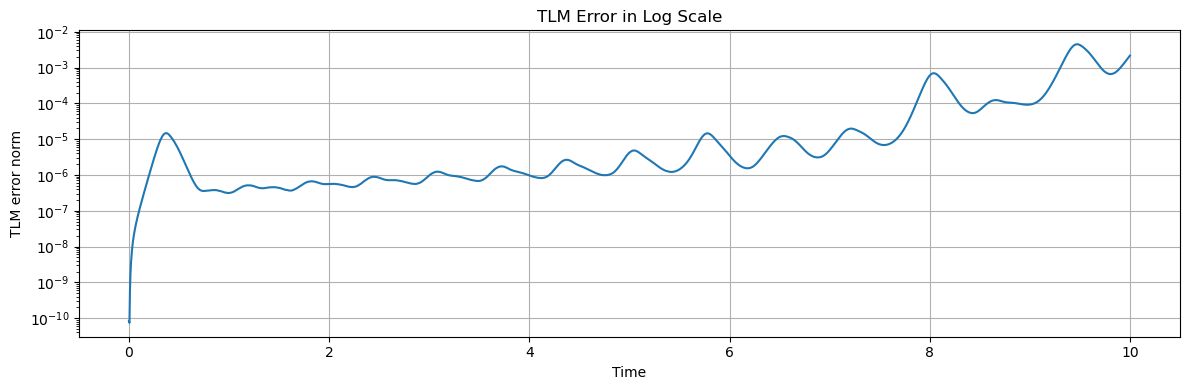

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_tlm_error_log_scale.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.semilogy(time, tlm_error + 1.0e-30)

ax.set_xlabel("Time")
ax.set_ylabel("TLM error norm")
ax.set_title("TLM Error in Log Scale")
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "03_tlm_error_log_scale.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 15. perturbation 크기에 따른 TLM valid time 확인

TLM은 작은 perturbation에 대해 유효한 선형 근사이다.

이번에는 여러 perturbation 크기 $\epsilon$에 대해 nonlinear perturbation과 TLM perturbation의 차이를 비교한다.

사용할 perturbation 크기는 다음과 같다.

```text
1e-8, 1e-6, 1e-4, 1e-2

perturbation이 클수록 nonlinear effect가 커지므로 TLM과 더 빨리 달라질 수 있다.

In [15]:
epsilon_list = [1.0e-8, 1.0e-6, 1.0e-4, 1.0e-2]

tlm_error_by_eps = {}

for eps in epsilon_list:
    x0_pert_eps = x0_ref + eps * delta0_direction

    trajectory_pert_eps = integrate_euler(
        x0=x0_pert_eps,
        dt=dt,
        nsteps=nsteps,
        rhs_func=lorenz63_rhs,
    )

    nonlinear_delta_eps = (trajectory_pert_eps - trajectory_ref) / eps

    error_eps = np.linalg.norm(nonlinear_delta_eps - tlm_delta, axis=1)

    tlm_error_by_eps[eps] = error_eps

    print(f"epsilon = {eps:.1e}, final error = {error_eps[-1]:.6e}")

epsilon = 1.0e-08, final error = 3.929901e-03
epsilon = 1.0e-06, final error = 2.151968e-03
epsilon = 1.0e-04, final error = 2.162391e-01
epsilon = 1.0e-02, final error = 2.083631e+01


## 16. perturbation 크기별 TLM error 비교

서로 다른 perturbation 크기에서 TLM error가 어떻게 변하는지 비교한다.

작은 perturbation에서는 TLM이 더 오래 잘 맞고, 큰 perturbation에서는 선형 근사가 더 빨리 깨질 수 있다.

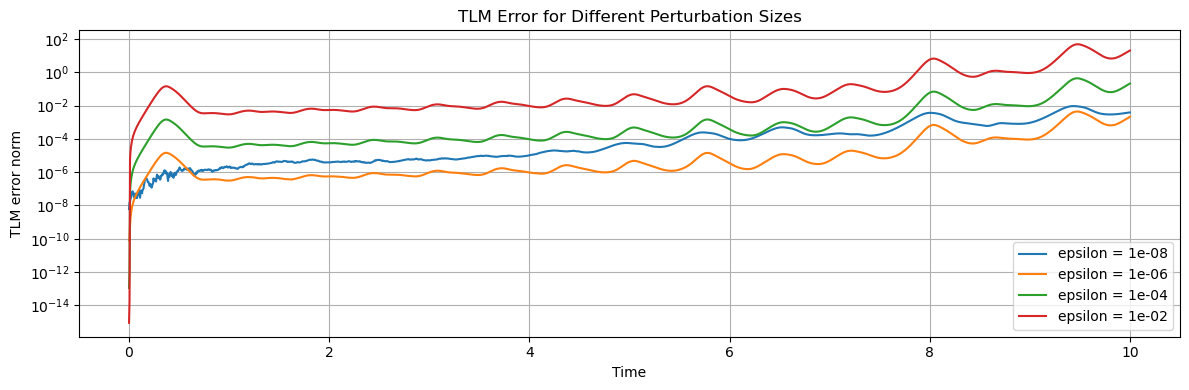

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_tlm_error_by_epsilon.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

for eps in epsilon_list:
    ax.semilogy(
        time,
        tlm_error_by_eps[eps] + 1.0e-30,
        label=f"epsilon = {eps:.0e}",
    )

ax.set_xlabel("Time")
ax.set_ylabel("TLM error norm")
ax.set_title("TLM Error for Different Perturbation Sizes")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "03_tlm_error_by_epsilon.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 17. TLM perturbation norm 확인

TLM perturbation 자체의 크기도 시간에 따라 변한다.

Lorenz-63 시스템은 chaotic system이므로 작은 perturbation이 특정 시간 동안 빠르게 성장할 수 있다.

여기서는 다음 값을 확인한다.

$$
\left\|
\delta \mathbf{x}_{TLM}(t)
\right\|_2
$$

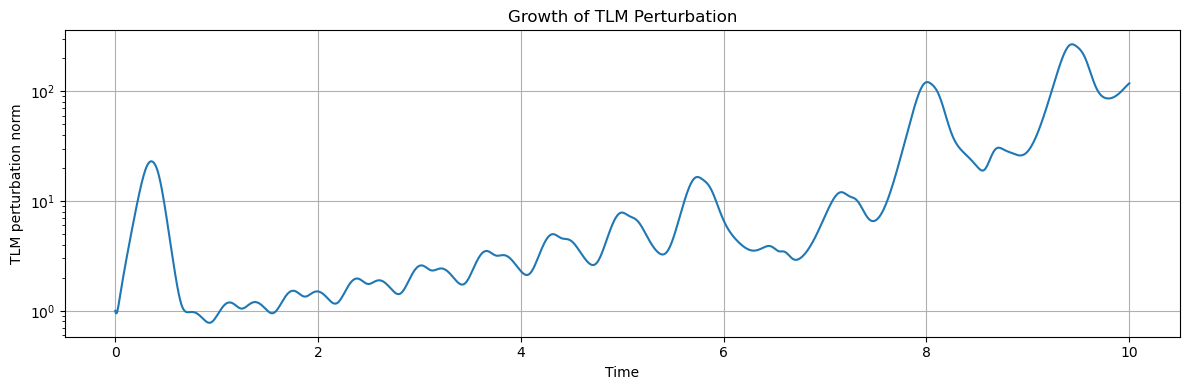

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_tlm_perturbation_norm.png
Initial norm: 1.0
Final norm: 118.55772083843272


In [17]:
tlm_norm = np.linalg.norm(tlm_delta, axis=1)

fig, ax = plt.subplots(figsize=(12, 4))

ax.semilogy(time, tlm_norm)

ax.set_xlabel("Time")
ax.set_ylabel("TLM perturbation norm")
ax.set_title("Growth of TLM Perturbation")
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "03_tlm_perturbation_norm.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)
print("Initial norm:", tlm_norm[0])
print("Final norm:", tlm_norm[-1])

## 18. 짧은 시간 구간에서의 비교

TLM은 긴 시간 동안 nonlinear perturbation을 정확히 따라가는 모델이 아니다.

TLM은 기준 trajectory 주변에서 작은 perturbation의 선형 성장을 근사하는 모델이다.

따라서 짧은 시간 구간에서 비교하면 TLM과 nonlinear perturbation이 더 잘 맞는 것을 볼 수 있다.

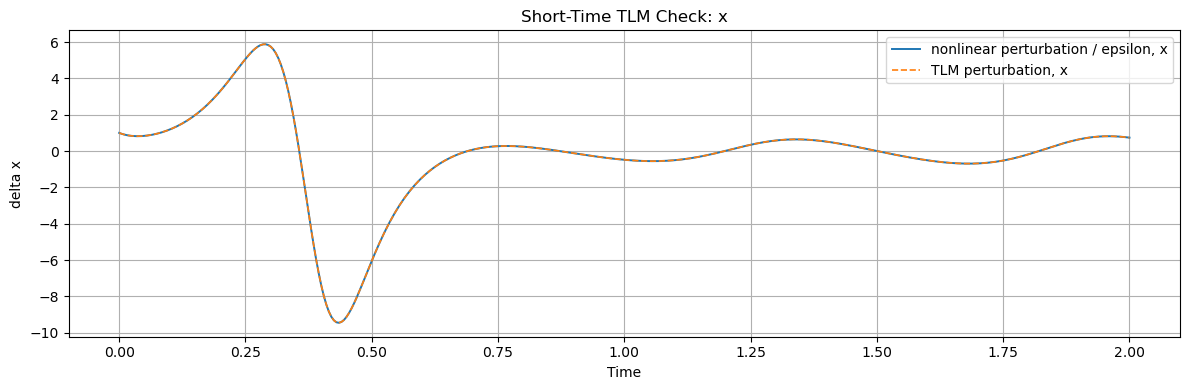

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_short_time_tlm_check_x.png


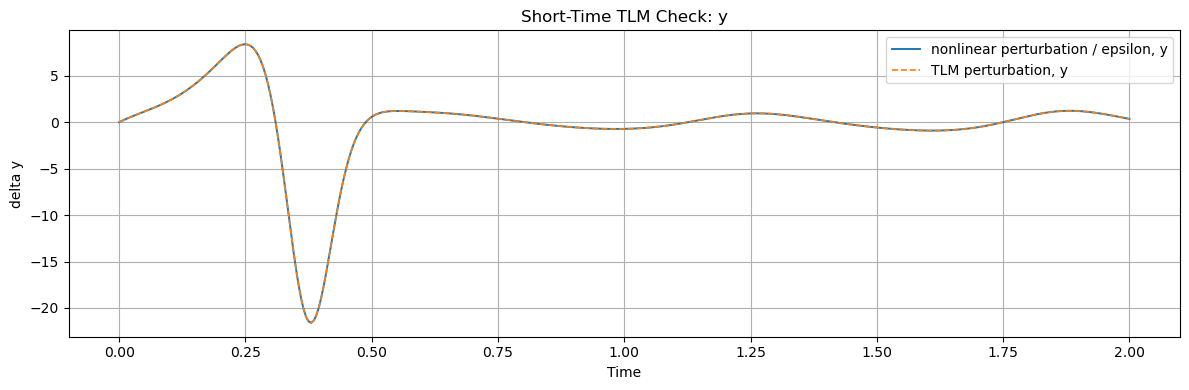

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_short_time_tlm_check_y.png


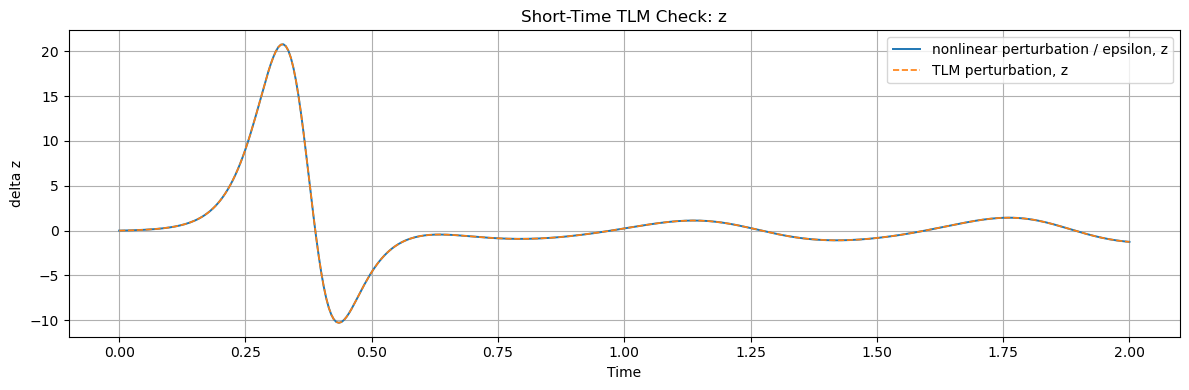

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/03_short_time_tlm_check_z.png


In [18]:
short_time_limit = 2.0
short_mask = time <= short_time_limit

for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        time[short_mask],
        nonlinear_delta[short_mask, i],
        label=f"nonlinear perturbation / epsilon, {name}",
        linewidth=1.4,
    )
    ax.plot(
        time[short_mask],
        tlm_delta[short_mask, i],
        label=f"TLM perturbation, {name}",
        linestyle="--",
        linewidth=1.2,
    )

    ax.set_xlabel("Time")
    ax.set_ylabel(f"delta {name}")
    ax.set_title(f"Short-Time TLM Check: {name}")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"03_short_time_tlm_check_{name}.png"
    fig.savefig(fig_path, dpi=150)

    plt.show()

    print("Saved figure:", fig_path)

## 19. 결과 저장

이번 실습에서 사용한 reference trajectory, nonlinear perturbation, TLM perturbation을 저장한다.

In [19]:
np.save(TRAJECTORY_DIR / "03_tlm_reference_trajectory.npy", trajectory_ref)
np.save(TRAJECTORY_DIR / "03_nonlinear_delta_eps1e-6.npy", nonlinear_delta)
np.save(TRAJECTORY_DIR / "03_tlm_delta.npy", tlm_delta)
np.save(TRAJECTORY_DIR / "03_tlm_time.npy", time)

print("Saved reference trajectory and TLM results.")
print("Output directory:", TRAJECTORY_DIR)

Saved reference trajectory and TLM results.
Output directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/trajectories


## 20. 이번 실습 정리

이번 노트북에서는 Lorenz-63 tangent linear model을 구현하고 검증했다.

확인한 내용은 다음과 같다.

1. Lorenz-63 RHS의 Jacobian을 유도했다.
2. Euler time stepping에 대한 TLM matrix를 구성했다.
3. finite-difference check로 Jacobian과 Euler TLM step을 검증했다.
4. nonlinear perturbation과 TLM perturbation을 비교했다.
5. perturbation이 작고 시간이 짧을 때 TLM이 잘 맞는다는 것을 확인했다.
6. perturbation이 커지거나 시간이 길어지면 nonlinear effect 때문에 TLM 근사가 깨질 수 있음을 확인했다.

이번 실습의 핵심 식은 다음이다.

$$
\delta \mathbf{x}_{n+1}
=
\left[
I + \Delta t J(\mathbf{x}_n)
\right]
\delta \mathbf{x}_n
$$

다음 실습에서는 이 TLM에 대응하는 adjoint model을 만들고, inner product test로 검증한다.

In [20]:
print("세 번째 실습 완료")
print("다음 실습: 04_lorenz63_adjoint_check.ipynb")

세 번째 실습 완료
다음 실습: 04_lorenz63_adjoint_check.ipynb
